# Analyses of extremes

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import dask.dataframe as dd

from scipy.ndimage import binary_closing as binary_closing
from scipy.ndimage import binary_opening as binary_opening
from scipy.ndimage import label as scipy_label
from scipy.ndimage import sum as scipy_sum
from skimage.measure import regionprops


import os
import seaborn as sns
import intake
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:

#from dask_image.ndmorph import binary_opening, binary_closing 


import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')
scratch_dir = Path('/scratch') / getuser()[0] / getuser()

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/8787/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/8787/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44299,Workers: 0
Dashboard: /user/b382616/levante-spawner-advanced//proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42527,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/38371/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:45701,


2025-12-30 09:49:55,568 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b126dbb1a0e790dd4c3c5021c903c9e1 initialized by task ('getitem-open_dataset-rechunk-transfer-5fc1a58c6eabea5da579299e3cab2ffc', 0, 0, 0, 12, 0, 0) executed on worker tcp://127.0.0.1:45067
2025-12-30 09:50:00,062 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 43b302d0145e92c1a494bec45e169c01 initialized by task ('getitem-ne-overlap-rechunk-trim-rechunk-transfer-b37d52713653233822e3a911506699b0', 0, 0, 0, 0, 4, 14) executed on worker tcp://127.0.0.1:46773
2025-12-30 09:50:17,125 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b126dbb1a0e790dd4c3c5021c903c9e1 deactivated due to stimulus 'task-finished-1767084617.054086'
2025-12-30 09:51:06,180 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 43b302d0145e92c1a494bec45e169c01 deactivated due to stimulus 'task-finished-1767084666.1398938'
2025-12-30 09:55:41,392 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b1

# LOAD DATA


In [19]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [20]:
#SST

# OSTIA
filename='/scratch/b/b382615/mhws/ostia.zarr' 
sst = xr.open_zarr(str(filename), chunks={'time':150, 'lat':-1, 'lon':-1}).sst
sst=sst.sel(lat=slice(-50, 70))
sst=sst-273.15

# ICON HISTORICAL
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_ic = dat['2d_daily_mean'](chunks={}).to_dask().to.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_ic=sst_ic.sel(lat=slice(-50, 70))


# IFS FESOM
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.ifs-fesom2-sr.hist-1950.v20240304.ocean.gr025']#.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_f = dat['2D_daily_avg_1950-2014'].to_dask().avg_tos.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_f=sst_f.sel(lat=slice(-50, 70))



In [5]:
# HADGEM LL
sst_LL = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/LL/toscon_nemo_u-da156_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_LL=sst_LL['toscon'].sel(lat=slice(-50, 70))


# HADGEM MM
sst_MM = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/MM/toscon_nemo_u-dc396_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_MM=sst_MM['toscon'].sel(lat=slice(-50, 70))


# HADGEM HH
sst_HH = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/HH/toscon_nemo_u-di356_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_HH=sst_HH['toscon'].sel(lat=slice(-50, 70))

            


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


## FIXED BASELINE

In [30]:


# FIXED BASELINES

# OSTIA ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
ossta=ds['dat_anomaly']
sst=sst.sel(time=slice((ossta.time[0].values),str(ossta.time[-1].values))) #making sure SST time matches SSTA time before masking the sea ice
ossta=ossta.where(sst>-1.7) #remove from anomalies places and times where there is sea ice



# ICON HIST ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
sst_ic=lon_180w_180e(sst_ic)
i_ds = i_ds.sel(lat=slice(-50, 70))
issta=i_ds['dat_anomaly']
sst_ic=sst_ic.sel(time=slice(str(issta.time[0].values),str(issta.time[-1].values)))
# Now apply the sea ice mask
issta = issta.where(sst_ic > -1.7)



# IFS-FESOM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
sst_f=lon_180w_180e(sst_f)
f_ds = f_ds.sel(lat=slice(-50, 70))
fssta=f_ds['dat_anomaly']
sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# Now apply the sea ice mask
fssta = fssta.where(sst_f > -1.7)


In [7]:


# HADGEM LL ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LLssta=LL_ds['dat_anomaly']
sst_LL=sst_LL.sel(time=slice((LLssta.time[0].values),str(LLssta.time[-1].values)))
# Now apply the sea ice mask
LLssta = LLssta.where(sst_LL > -1.7)

# HADGEM MM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MMssta=MM_ds['dat_anomaly']
sst_MM=sst_MM.sel(time=slice((MMssta.time[0].values),str(MMssta.time[-1].values)))
# Now apply the sea ice mask
MMssta = MMssta.where(sst_MM > -1.7)


# HADGEM HH ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HHssta=HH_ds['dat_anomaly']
sst_HH=sst_HH.sel(time=slice((HHssta.time[0].values),str(HHssta.time[-1].values)))
# Now apply the sea ice mask
HHssta = HHssta.where(sst_HH> -1.7)


/tmp/ipykernel_2507397/481346273.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_2507397/481346273.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_2507397/481346273.py:29: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


In [22]:
# OSTIA EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
o_ex=ds['extreme_events']
sst=sst.sel(time=slice((o_ex.time[0].values),str(o_ex.time[-1].values)))





# ICON HIST EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
i_ds = i_ds.sel(lat=slice(-50, 70))
i_ex=i_ds['extreme_events']
sst_ic=sst_ic.sel(time=slice(str(i_ex.time[0].values),str(i_ex.time[-1].values)))

# For extreme events (boolean)
i_ex_float = i_ex.astype(float)  # Convert to 0.0 and 1.0
#i_ex_interp = i_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
i_ex = i_ex_float > 0.5  # Convert back to boolean if needed





# IFS-FESOM EXTREMES
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_dec25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
f_ds = f_ds.sel(lat=slice(-50, 70))
f_ex=f_ds['extreme_events']
#fssta=f_ds['dat_anomaly']
#sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# For extreme events (boolean)
f_ex_float = f_ex.astype(float)  # Convert to 0.0 and 1.0
#f_ex_interp = f_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
f_ex = f_ex_float > 0.5  # Convert back to boolean if needed



In [9]:


# HADGEM LL EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LL_ex=LL_ds['extreme_events']
#LLssta=LL_ds['dat_anomaly']
LL_ex_float = LL_ex.astype(float) 
LL_ex = LL_ex_float > 0.5 

# HADGEM MM EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MM_ex=MM_ds['extreme_events']
#MMssta=MM_ds['dat_anomaly']
MM_ex_float = MM_ex.astype(float) 
MM_ex = MM_ex_float > 0.5 


# HADGEM HH EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HH_ex=HH_ds['extreme_events']
#HHssta=HH_ds['dat_anomaly']
HH_ex_float = HH_ex.astype(float) 
HH_ex = HH_ex_float > 0.5 


/tmp/ipykernel_2507397/3477229959.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_2507397/3477229959.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_2507397/3477229959.py:29: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


# AREAS and REGIONAL ASSIGNMENT

In [10]:
ds=HH_ds
o_ex=HH_ex
ossta=HHssta

In [23]:

from scipy.ndimage import binary_closing as scipy_binary_closing
from scipy.ndimage import binary_opening as scipy_binary_opening
from scipy.ndimage import label as scipy_label
from scipy.ndimage import sum as scipy_sum
from skimage.measure import regionprops
from dask_image.ndmorph import binary_opening as dask_binary_opening
from dask_image.ndmorph import binary_closing as dask_binary_closing

# 24/12/25 - INTEGRATED TEMPORAL & SPATIAL MHW PROCESSOR

# --- 1. PREP MASK & WEIGHTS ---
land_mask_2d = ds.mask.compute().values.astype(bool)

# Calculate physical area weights (km2) for a spherical Earth
R_earth = 6371.0
res = 0.25
lat_r = np.radians(ds.lat)
dlat, dlon = np.radians(res), np.radians(res)
grid_area_2d = (R_earth**2 * np.abs(np.sin(lat_r + dlat/2) - np.sin(lat_r - dlat/2)) * dlon).astype(np.float32)
grid_area_2d_slice = (xr.ones_like(ds.extreme_events.isel(time=0)) * grid_area_2d).values

# --- 2. TEMPORAL CLEANING (Hobday Logic) ---
# Enforce 5-day minimum duration and close gaps of up to 2 days
T_fill, T_min = 2, 5
# Structures act on (Time, Lat, Lon). We only want to bridge/filter along Time (dim 0).
time_open_struct = np.ones((T_min, 1, 1), dtype=bool)
time_close_struct = np.ones((T_fill + 1, 1, 1), dtype=bool)

print("Starting Temporal Filtering (5-day min, 2-day gap)...")
# Note: o_ex must be chunked significantly in time for this to be efficient
o_ex_raw = ds.extreme_events.chunk({'time': -1, 'lat': 100, 'lon': 100}) 

# 1. Opening: Remove events < 5 days
temp_cleaned = dask_binary_opening(o_ex_raw.data, structure=time_open_struct)
# 2. Closing: Fill gaps <= 2 days
temp_cleaned = dask_binary_closing(temp_cleaned, structure=time_close_struct)

# Wrap back to Xarray and re-chunk for spatial processing (1 day per chunk)
o_ex_filtered = xr.DataArray(temp_cleaned, coords=ds.extreme_events.coords, dims=ds.extreme_events.dims)
o_ex_filtered = o_ex_filtered.chunk({'time': 1, 'lat': -1, 'lon': -1})

# --- 3. THE SPATIAL PROCESSOR (Stitching & Area) ---
def dask_safe_processor(binary_slice, area_weights, lats, lons, land_mask):
    # Ensure strict ocean-only input
    data = binary_slice.astype(bool) & land_mask
    
    R_fill = 3
    kernel = np.ones((R_fill*2+1, R_fill*2+1))
    
    # A. Spatial Closing (Fill Gaps) with Padding for Dateline
    pad = 10
    wrapped = np.pad(data, ((0,0), (pad, pad)), mode='wrap')
    closed = scipy_binary_closing(wrapped, structure=kernel)
    
    # B. THE FIREWALL: Re-mask to kill continental "crawling"
    cleaned = closed[:, pad:-pad] & land_mask
    
    # C. Opening (Remove small spatial noise)
    opened = scipy_binary_opening(cleaned, structure=kernel) & land_mask
    
    # D. Labeling (Connectivity)
    pad_l = 20
    padded_l = np.pad(opened, ((0,0), (pad_l, pad_l)), mode='wrap')
    lbl_p, n = scipy_label(padded_l, structure=np.ones((3,3)))
    
    if n == 0:
        return np.zeros((4, binary_slice.shape[0], binary_slice.shape[1]), dtype=np.float32)

    # E. UNWRAP & DATELINE STITCHING
    lbl = (lbl_p[:, pad_l:-pad_l] * land_mask).astype(np.int32)
    left_edge, right_edge = lbl[:, 0], lbl[:, -1]
    matches = np.unique(np.stack([left_edge, right_edge]), axis=1)
    
    for i in range(matches.shape[1]):
        id_l, id_r = matches[0, i], matches[1, i]
        if id_l > 0 and id_r > 0 and id_l != id_r:
            lbl[lbl == id_r] = id_l

    # F. AREA CALCULATION
    unique_ids = np.unique(lbl[lbl > 0])
    sums = scipy_sum(area_weights, lbl, index=unique_ids)
    area_lookup = np.zeros(lbl.max() + 1, dtype=np.float32)
    for i, blob_id in enumerate(unique_ids):
        area_lookup[blob_id] = sums[i]
    area_map = area_lookup[lbl]
    
    # G. CENTROIDS
    y_c_map, x_c_map = np.zeros_like(area_map), np.zeros_like(area_map)
    props = regionprops(lbl)
    y_idx_arr, x_idx_arr = np.arange(len(lats)), np.arange(len(lons))
    for prop in props:
        y_c, x_c = prop.centroid
        y_c_map[lbl == prop.label] = np.interp(y_c, y_idx_arr, lats)
        x_c_map[lbl == prop.label] = np.interp(x_c, x_idx_arr, lons)

    return np.stack([lbl.astype(np.float32), area_map, y_c_map, x_c_map])

# --- 4. EXECUTION ---
print("Executing Spatial Labeling and Area calculation...")
results = xr.apply_ufunc(
    dask_safe_processor,
    o_ex_filtered,
    grid_area_2d_slice,
    o_ex_filtered.lat,
    o_ex_filtered.lon,
    land_mask_2d,
    input_core_dims=[["lat", "lon"], ["lat", "lon"], ["lat"], ["lon"], ["lat", "lon"]],
    output_core_dims=[["vars", "lat", "lon"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={'output_sizes': {"vars": 4}}
)

ds_result = xr.Dataset(
    {
        "ID_field": results.isel(vars=0).astype(np.int32),
        "mhw_area_km2": results.isel(vars=1),
        "centroid_lat": results.isel(vars=2),
        "centroid_lon": results.isel(vars=3),
    },
    coords=o_ex_filtered.coords
).transpose("time", "lat", "lon")

# --- 5. UNIQUE IDs ACROSS TIME ---
print("Calculating daily max IDs for temporal offsets...")
daily_max = ds_result.ID_field.max(dim=['lat', 'lon']).compute()
offsets = daily_max.cumsum(dim='time').shift(time=1, fill_value=0)
ds_result['unique_id'] = (ds_result.ID_field + offsets).where(ds_result.ID_field > 0, 0)

print("✅ SUCCESS: Temporal filtering applied, data stitched, and Unique IDs generated.")

Starting Temporal Filtering (5-day min, 2-day gap)...
Executing Spatial Labeling and Area calculation...
Calculating daily max IDs for temporal offsets...
✅ SUCCESS: Temporal filtering applied, data stitched, and Unique IDs generated.


In [12]:

#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_area_mhws.zarr'
#ds_result.to_zarr(file_name, mode="w", zarr_version=2)

#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'iconhist_area_mhws.zarr'
#ds_result.to_zarr(file_name, mode="w", zarr_version=2)

#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ifsfesom_area_mhws.zarr'
#ds_result.to_zarr(file_name, mode="w", zarr_version=2)



#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'LL_area_mhws.zarr'
#ds_result.to_zarr(file_name, mode="w")

#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_area_mhws.zarr'
#ds_result.to_zarr(file_name, mode="w")

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'HH_area_mhws.zarr'
ds_result.to_zarr(file_name, mode="w")

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 15.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [3]:
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'HH_area_mhws.zarr'
ds_result=xr.open_zarr(file_name)

In [4]:
# ASSIGN AREAS TO REGIONS

In [4]:
all_models = ['HadGEM3-HH']

In [5]:
all_models = ['IFS-FESOM']

In [5]:
# LOAD MASKS


mask_save_dir = Path('/scratch/b/b382616/mhws/DV8/extremes_model_masks')

# All model names

masks_dict = {}

for model in all_models:
    # Find the mask file for this model
    mask_files = list(mask_save_dir.glob(f'*{model}*.zarr'))
    
    if mask_files:
        mask_file = mask_files[0]
        print(f"Loading {model} mask from {mask_file.name}")
        
        mask_ds = xr.open_zarr(str(mask_file))
        
        # For HadGEM models, select latitude range
        if model.startswith('HadGEM3-'):
            mask_ds = mask_ds.sel(lat=slice(-50, 70))
            print(f"  Selected lat range -50 to 70")
        
        masks_dict[model] = mask_ds
        print(f"  ✓ Loaded {len(mask_ds.data_vars)} regions")
    else:
        print(f"Warning: No mask file found for {model}")

print(f"\nSuccessfully loaded masks for {len(masks_dict)} models")

Loading HadGEM3-HH mask from extremes_HadGEM3-HH_721x1440_-4232089158561518125_region_masks.zarr
  Selected lat range -50 to 70
  ✓ Loaded 15 regions

Successfully loaded masks for 1 models


In [ ]:
# MAIN CODE: HERE WE ASSIGN AREAS AND BLOBS TO REGIONS

In [6]:
# 1. OSTIA: Create the 2D Region Map (The Arena)

competitive_regions = [r for r in masks_dict['OSTIA'].keys() if r != 'Pacific_Equatorial']
region_names = list(competitive_regions)
region_id_map = np.zeros(ds_result.unique_id.isel(time=0).shape, dtype=np.int16)

for i, name in enumerate(region_names):
    mask_2d = masks_dict['OSTIA'][name].reindex_like(ds_result, method='nearest', fill_value=False).values
    region_id_map[mask_2d] = i + 1


In [6]:
# all the other models

competitive_regions = [r for r in masks_dict['HadGEM3-HH'].keys() if r != 'Pacific_Equatorial']
region_names = list(competitive_regions)
region_id_map = np.zeros(ds_result.unique_id.isel(time=0).shape, dtype=np.int16)

for i, name in enumerate(region_names):
    # We take the values and immediately force them to boolean
    # This turns 1.0 -> True and 0.0 -> False
    mask_2d = masks_dict['HadGEM3-HH'][name].reindex_like(
        ds_result, method='nearest'
    ).values.astype(bool) 
    
    region_id_map[mask_2d] = i + 1

In [7]:



# 2. Process Block Logic (Fixed to prevent double-summing area)
def process_block(ds_chunk, region_map_2d):
    ids = ds_chunk.unique_id.values
    areas = ds_chunk.mhw_area_km2.values
    regions = np.broadcast_to(region_map_2d, ids.shape).ravel()
    
    ids_flat = ids.ravel()
    areas_flat = areas.ravel()
    
    valid = ids_flat > 0
    if not np.any(valid):
        return pd.DataFrame()

    df = pd.DataFrame({
        'id': ids_flat[valid],
        'region_idx': regions[valid],
        'area_val': areas_flat[valid]
    })
    
    # We group by ID and Region
    # 'size' counts pixels (for voting)
    # 'mean' gets the area (since every pixel of an ID has the same area value)
    return df.groupby(['id', 'region_idx'])['area_val'].agg(['size', 'mean']).reset_index()

# 3. Parallel Execution
print("Starting Voting Process (this may take a few minutes)...")
chunk_size = 100 # Process 100 days at a time
time_indices = np.arange(len(ds_result.time))
chunks = [time_indices[i:i + chunk_size] for i in range(0, len(time_indices), chunk_size)]

all_delayed = [dask.delayed(process_block)(ds_result.isel(time=c), region_id_map) for c in chunks]
computed = dask.compute(*all_delayed)

# Combine results
df_all_votes = pd.concat([c for c in computed if not c.empty])

# 4. Final Assignment
# Winner = Region with the most pixels ('size')
final_votes = df_all_votes.groupby(['id', 'region_idx']).agg({'size': 'sum', 'mean': 'mean'}).reset_index()
df_assignments = final_votes.sort_values('size', ascending=False).drop_duplicates('id').copy()

# Map names and units
region_lookup = {i + 1: name for i, name in enumerate(region_names)}
region_lookup[0] = 'Open_Ocean'
df_assignments['assigned_region'] = df_assignments['region_idx'].map(region_lookup)
df_assignments['total_area_km2'] = df_assignments['mean']

print(f"✅ Success! Max Area: {df_assignments['total_area_km2'].max():,.0f} km^2")

Starting Voting Process (this may take a few minutes)...


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 55.18 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


✅ Success! Max Area: 40,956,552 km^2


In [8]:
# Convert the Pandas DataFrame to an Xarray Dataset
# We set 'id' as the coordinate so you can easily link it back to the gridded data
ds_assignments = df_assignments.set_index('id').to_xarray()
#save_path_assignments = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / '1ostia_regional_area.zarr'
#save_path_assignments = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'iconhist_regional_area.zarr'
#save_path_assignments = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ifsfesom_regional_area.zarr'
#ds_assignments.to_zarr(save_path_assignments, mode="w", zarr_version=2, consolidated=True)

#save_path_assignments = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'LL_regional_area.zarr'
#save_path_assignments = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_regional_area.zarr'
save_path_assignments = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'HH_regional_area.zarr'
ds_assignments.to_zarr(save_path_assignments, mode="w")


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### Old method

In [7]:
# --- 1. INITIAL SETUP & CHUNKING ---
o_ex = o_ex.chunk({'time': 1, 'lat': -1, 'lon': -1})
data_bin = o_ex
# Get land mask (True where there is water, False where there is land)
land_mask = o_ex.isel(time=0).notnull().compute()

# --- 2. TEMPORAL CLEANING ---
T_fill, T_min = 2, 5
time_close = np.ones(T_fill + 1, dtype=bool)
time_open = np.ones(T_min, dtype=bool)

data_opened = binary_opening(data_bin.data, structure=time_open[:, np.newaxis, np.newaxis])
data_mhws = binary_closing(data_opened, structure=time_close[:, np.newaxis, np.newaxis])

# --- 3. SPATIAL CLEANING (WITH LAND MASK) ---
# Apply land mask BEFORE spatial operations to prevent ocean-hopping
data_mhws_masked = data_mhws * land_mask.values[np.newaxis, :, :]

R_fill = 3
spatial_kernel = np.ones((R_fill * 2 + 1, R_fill * 2 + 1))

# Use the MASKED data here
data_sp_closed = binary_closing(data_mhws_masked, structure=spatial_kernel[np.newaxis, :])
# Re-apply land mask after closing just to be safe (closing can expand blobs into land)
data_sp_closed = data_sp_closed * land_mask.values[np.newaxis, :, :]
data_sp_opened = binary_opening(data_sp_closed, structure=spatial_kernel[np.newaxis, :])

da_mhws_clean = xr.DataArray(
    data_sp_opened, 
    coords=data_bin.coords, 
    dims=data_bin.dims, 
    name="MHW_binary"
)

NameError: name 'data_mhws' is not defined

In [9]:
# --- 3. GRID AREA WEIGHTS ---

R_earth = 6371.0  # km
resolution = 0.25  # deg

lat_r, lon_r, dlat, dlon = (
    np.radians(da_mhws_clean.lat),
    np.radians(da_mhws_clean.lon),
    np.radians(resolution),
    np.radians(resolution),
)

# This creates a 3D field based on your code
grid_area_3d = (xr.ones_like(da_mhws_clean) * (R_earth**2 * np.abs(np.sin(lat_r + dlat / 2) - np.sin(lat_r - dlat / 2)) * dlon)).astype(np.float32)

# We take just one 2D slice to pass into the ufunc to save memory
grid_area_2d_slice = grid_area_3d.isel(time=0).drop_vars('time').values

In [10]:
# NEW


# --- 1. THE REWRITTEN PROCESSOR (v3) ---
# This version includes circular wrapping to prevent the Dateline Split

def standalone_mhw_processor_v3(mask_slice, area_weights_2d, lats_1d, lons_1d):
    """
    Processes a single 2D time slice to label blobs, calculate area, 
    and find centroids while respecting longitudinal wrapping.
    """
    # 1. Longitude Wrapping & Labeling
    # We use a 10-pixel wrap to ensure the labeling engine sees the 
    # connection across the edges of the array.
    pad_w = 10
    padded_mask = np.pad(mask_slice, ((0, 0), (pad_w, pad_w)), mode='wrap')
    
    # Label the wrapped mask
    lbl_padded, n = scipy_label(padded_mask, structure=np.ones((3, 3)))
    
    if n == 0:
        empty_int = np.zeros_like(mask_slice, dtype=np.int32)
        empty_float = np.zeros_like(mask_slice, dtype=np.float32)
        return empty_int, empty_int.astype(np.int64), empty_float, empty_float

    # Crop the labels back to the original longitude size
    lbl = lbl_padded[:, pad_w:-pad_w]
    indices = np.arange(1, n + 1)

    # 2. Compute Areas (Already in km2 based on your grid_area_2d_slice)
    areas = scipy_sum(area_weights_2d, lbl, index=indices)
    area_lookup = np.insert(np.round(areas).astype(np.int64), 0, 0)
    area_map = area_lookup[lbl]

    # 3. Compute Centroids (Physical Coordinates)
    props = regionprops(lbl)
    
    y_cent_map = np.zeros_like(lbl, dtype=np.float32)
    x_cent_map = np.zeros_like(lbl, dtype=np.float32)
    
    # Pre-create index arrays for interpolation
    y_indices = np.arange(len(lats_1d))
    x_indices = np.arange(len(lons_1d))
    
    for prop in props:
        y_idx, x_idx = prop.centroid
        
        # Interpolate fractional pixel indices to actual lat/lon values
        # This ensures centroids are in degrees, not pixel coordinates
        actual_lat = np.interp(y_idx, y_indices, lats_1d)
        actual_lon = np.interp(x_idx, x_indices, lons_1d)
        
        # Assign the centroid coordinate to every pixel belonging to this blob
        mask = (lbl == prop.label)
        y_cent_map[mask] = actual_lat
        x_cent_map[mask] = actual_lon

    return lbl.astype(np.int32), area_map, y_cent_map, x_cent_map

# --- 2. EXECUTION VIA APPLY_UFUNC ---

results = xr.apply_ufunc(
    standalone_mhw_processor_v3,
    da_mhws_clean,         # The cleaned binary field from the previous step
    grid_area_2d_slice,
    da_mhws_clean.lat,
    da_mhws_clean.lon,
    input_core_dims=[["lat", "lon"], ["lat", "lon"], ["lat"], ["lon"]],
    output_core_dims=[["lat", "lon"], ["lat", "lon"], ["lat", "lon"], ["lat", "lon"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.int32, np.int64, np.float32, np.float32] 
)

# --- 3. DATASET PACKAGING ---

ds_result = xr.Dataset(
    {
        "ID_field": results[0],
        "mhw_area_km2": results[1],
        "centroid_lat": results[2],
        "centroid_lon": results[3],
    }
)

# Re-order dimensions to (time, lat, lon) for standard usage
ds_result = ds_result.transpose("time", "lat", "lon")

# --- 4. UNIQUE ID CREATION (DAILY OFFSETS) ---

# Calculate the max ID for each day to create unique global IDs
daily_max = ds_result.ID_field.max(dim=['lat', 'lon']).compute()
offsets = daily_max.cumsum(dim='time').shift(time=1, fill_value=0)

# Create unique IDs across the entire time series
ds_result['unique_id'] = (ds_result.ID_field + offsets).where(ds_result.ID_field > 0, 0)

In [9]:
# FIX CENTROIDS

# with centroidsssss


def standalone_mhw_processor_v2(mask_slice, area_weights_2d, lats_1d, lons_1d):
    # 1. Longitude Wrapping & Labeling
    padded_mask = np.pad(mask_slice, ((0, 0), (1, 1)), mode='wrap')
    lbl_padded, n = scipy_label(padded_mask, structure=np.ones((3, 3)))
    
    if n == 0:
        empty_int = np.zeros_like(mask_slice, dtype=np.int32)
        empty_float = np.zeros_like(mask_slice, dtype=np.float32)
        return empty_int, empty_int.astype(np.int64), empty_float, empty_float

    lbl = lbl_padded[:, 1:-1]
    indices = np.arange(1, n + 1)

    # 2. Compute Areas
    areas = scipy_sum(area_weights_2d, lbl, index=indices)
    area_lookup = np.insert(np.round(areas).astype(np.int64), 0, 0)
    area_map = area_lookup[lbl]

    # 3. Compute Centroids (Physical Coordinates)
    props = regionprops(lbl)
    
    y_cent_map = np.zeros_like(lbl, dtype=np.float32)
    x_cent_map = np.zeros_like(lbl, dtype=np.float32)
    
    # Pre-create index arrays for interpolation
    y_indices = np.arange(len(lats_1d))
    x_indices = np.arange(len(lons_1d))
    
    for prop in props:
        y_idx, x_idx = prop.centroid
        
        # Interpolate fractional pixel indices to actual lat/lon values
        actual_lat = np.interp(y_idx, y_indices, lats_1d)
        actual_lon = np.interp(x_idx, x_indices, lons_1d)
        
        y_cent_map[lbl == prop.label] = actual_lat
        x_cent_map[lbl == prop.label] = actual_lon

    return lbl.astype(np.int32), area_map, y_cent_map, x_cent_map



results = xr.apply_ufunc(
    standalone_mhw_processor_v2,
    da_mhws_clean,
    grid_area_2d_slice,
    da_mhws_clean.lat, # New input
    da_mhws_clean.lon, # New input
    input_core_dims=[["lat", "lon"], ["lat", "lon"], ["lat"], ["lon"]], # Updated core dims
    output_core_dims=[["lat", "lon"], ["lat", "lon"], ["lat", "lon"], ["lat", "lon"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.int32, np.int64, np.float32, np.float32] 
)


# Unpack the tuple into a Dataset
ds_result = xr.Dataset(
    {
        "ID_field": results[0],
        "mhw_area_km2": results[1],
        "centroid_lat": results[2],
        "centroid_lon": results[3],
    }
)

# Ensure dimensions are correctly ordered for the next steps
ds_result = ds_result.transpose("time", "lat", "lon")

In [10]:
#CREATING UNIQUE IDs FOR EACH BLOB


# 1. Get the max ID per day (This is fine as is)
daily_max = ds_result.ID_field.max(dim=['lat', 'lon']).compute()

# 2. Calculate offsets (This is fine as is)
offsets = daily_max.cumsum(dim='time').shift(time=1, fill_value=0)

# 3. Optimized unique_id creation
# Using a simple addition and then masking the zeros is often more efficient for Dask
unique_id = ds_result.ID_field + offsets
ds_result['unique_id'] = unique_id.where(ds_result.ID_field > 0, 0)

In [11]:
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_area_mhws.zarr'
#ds_result.to_zarr(file_name, mode="w", zarr_version=2)

#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'icon_area_mhws.zarr'
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_area_mhws_4.zarr'
ds_result.to_zarr(file_name, mode="w", zarr_version=2)

/tmp/ipykernel_4192377/2806057323.py:6: FutureWarning: zarr_version is deprecated, use zarr_format
  ds_result.to_zarr(file_name, mode="w", zarr_version=2)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 13.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


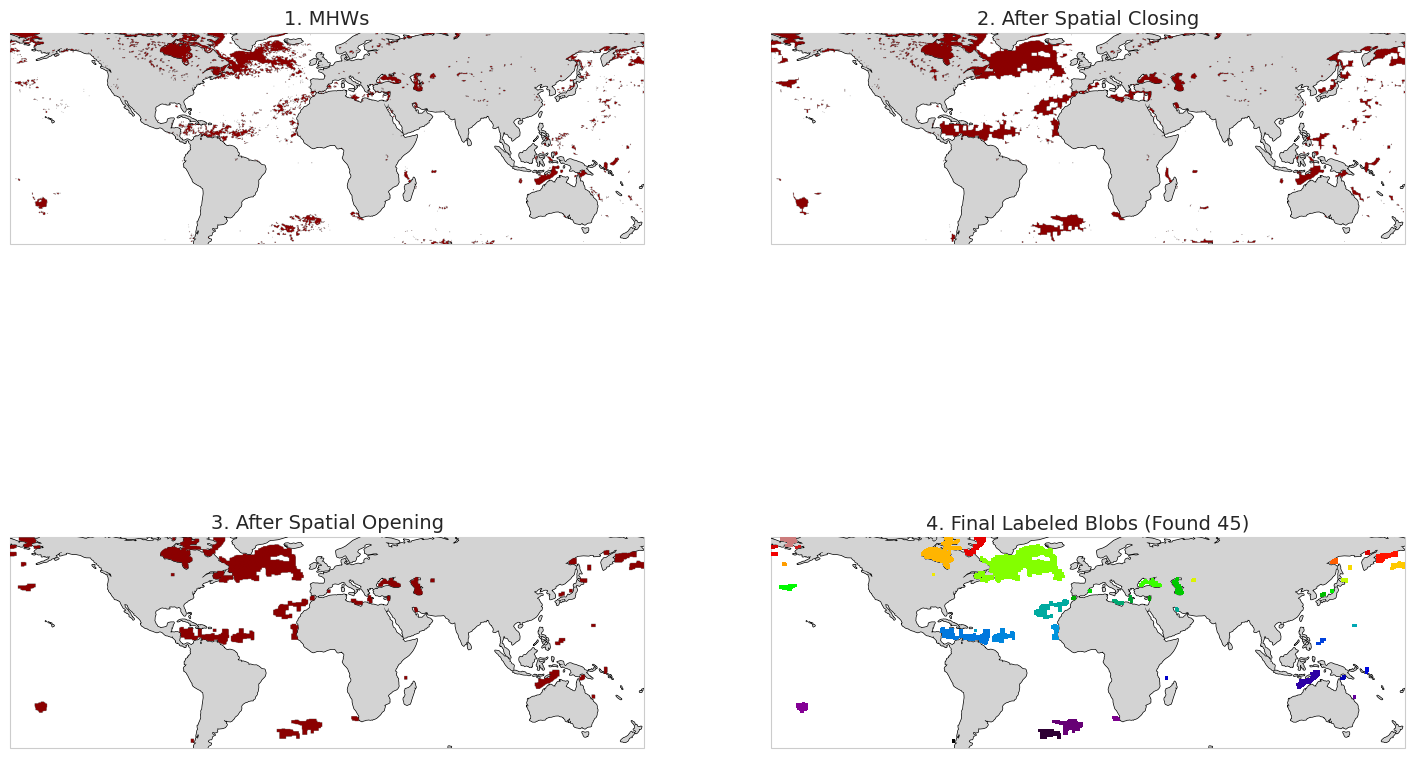

In [66]:

from matplotlib.colors import ListedColormap


# 1. Setup Projections & Extent
# Assuming your data is global PlateCarree (standard lat/lon)
data_proj = ccrs.PlateCarree()
# [lon_min, lon_max, lat_min, lat_max]
img_extent = [ds.lon.min(), ds.lon.max(), ds.lat.min(), ds.lat.max()]

# 2. Define Colormaps
red_cmp = ListedColormap(['none', 'darkred'])

# 3. Create Figure with Cartopy projection
fig, axes = plt.subplots(2, 2, figsize=(18, 12), 
                         subplot_kw={'projection': data_proj}, 
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- Plotting Functions ---

# Plot 1: Raw
axes[0].imshow(step1_raw, origin='lower', cmap=red_cmp, 
               extent=img_extent, transform=data_proj, zorder=10)
axes[0].set_title("1. MHWs", fontsize=14)

# Plot 2: After Closing
axes[1].imshow(step2_closed, origin='lower', cmap=red_cmp, 
               extent=img_extent, transform=data_proj, zorder=10)
axes[1].set_title("2. After Spatial Closing", fontsize=14)

# Plot 3: After Opening
axes[2].imshow(step3_opened, origin='lower', cmap=red_cmp, 
               extent=img_extent, transform=data_proj, zorder=10)
axes[2].set_title("3. After Spatial Opening", fontsize=14)

# Plot 4: Labels
axes[3].imshow(np.where(lbl > 0, lbl, np.nan), origin='lower', cmap='nipy_spectral', 
               extent=img_extent, transform=data_proj, zorder=10, interpolation='nearest')
axes[3].set_title(f"4. Final Labeled Blobs (Found {n})", fontsize=14)

# --- General Styling (Cartopy Features) ---
for ax in axes:
    # Set background to white (Ocean)
    ax.set_facecolor('white')
    
    # Add high-resolution Land (Black)
    # We use 'facecolor' for the land and 'edgecolor' for the coastline
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)





# REGIONAL PDFs

In [3]:

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_regional_area.zarr'
region_ostia=xr.open_zarr(file_name)


file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'iconhist_regional_area.zarr'
region_icon=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ifsfesom_regional_area.zarr'
region_ifs=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'LL_regional_area.zarr'
region_LL=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_regional_area.zarr'
region_MM=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_regional_area.zarr'
region_HH=xr.open_zarr(file_name)



In [4]:
models_dict = {
    'OSTIA': region_ostia,
    'ICON': region_icon,
    'IFS-FESOM': region_ifs,
    'HadGEM3-LL': region_LL,
    'HadGEM3-MM': region_MM,
    'HadGEM3-HH': region_HH # Ensure you fixed the path typo for HH!
}


Processing OSTIA...
Processing ICON...
Processing IFS-FESOM...
Processing HadGEM3-LL...
Processing HadGEM3-MM...
Processing HadGEM3-H...


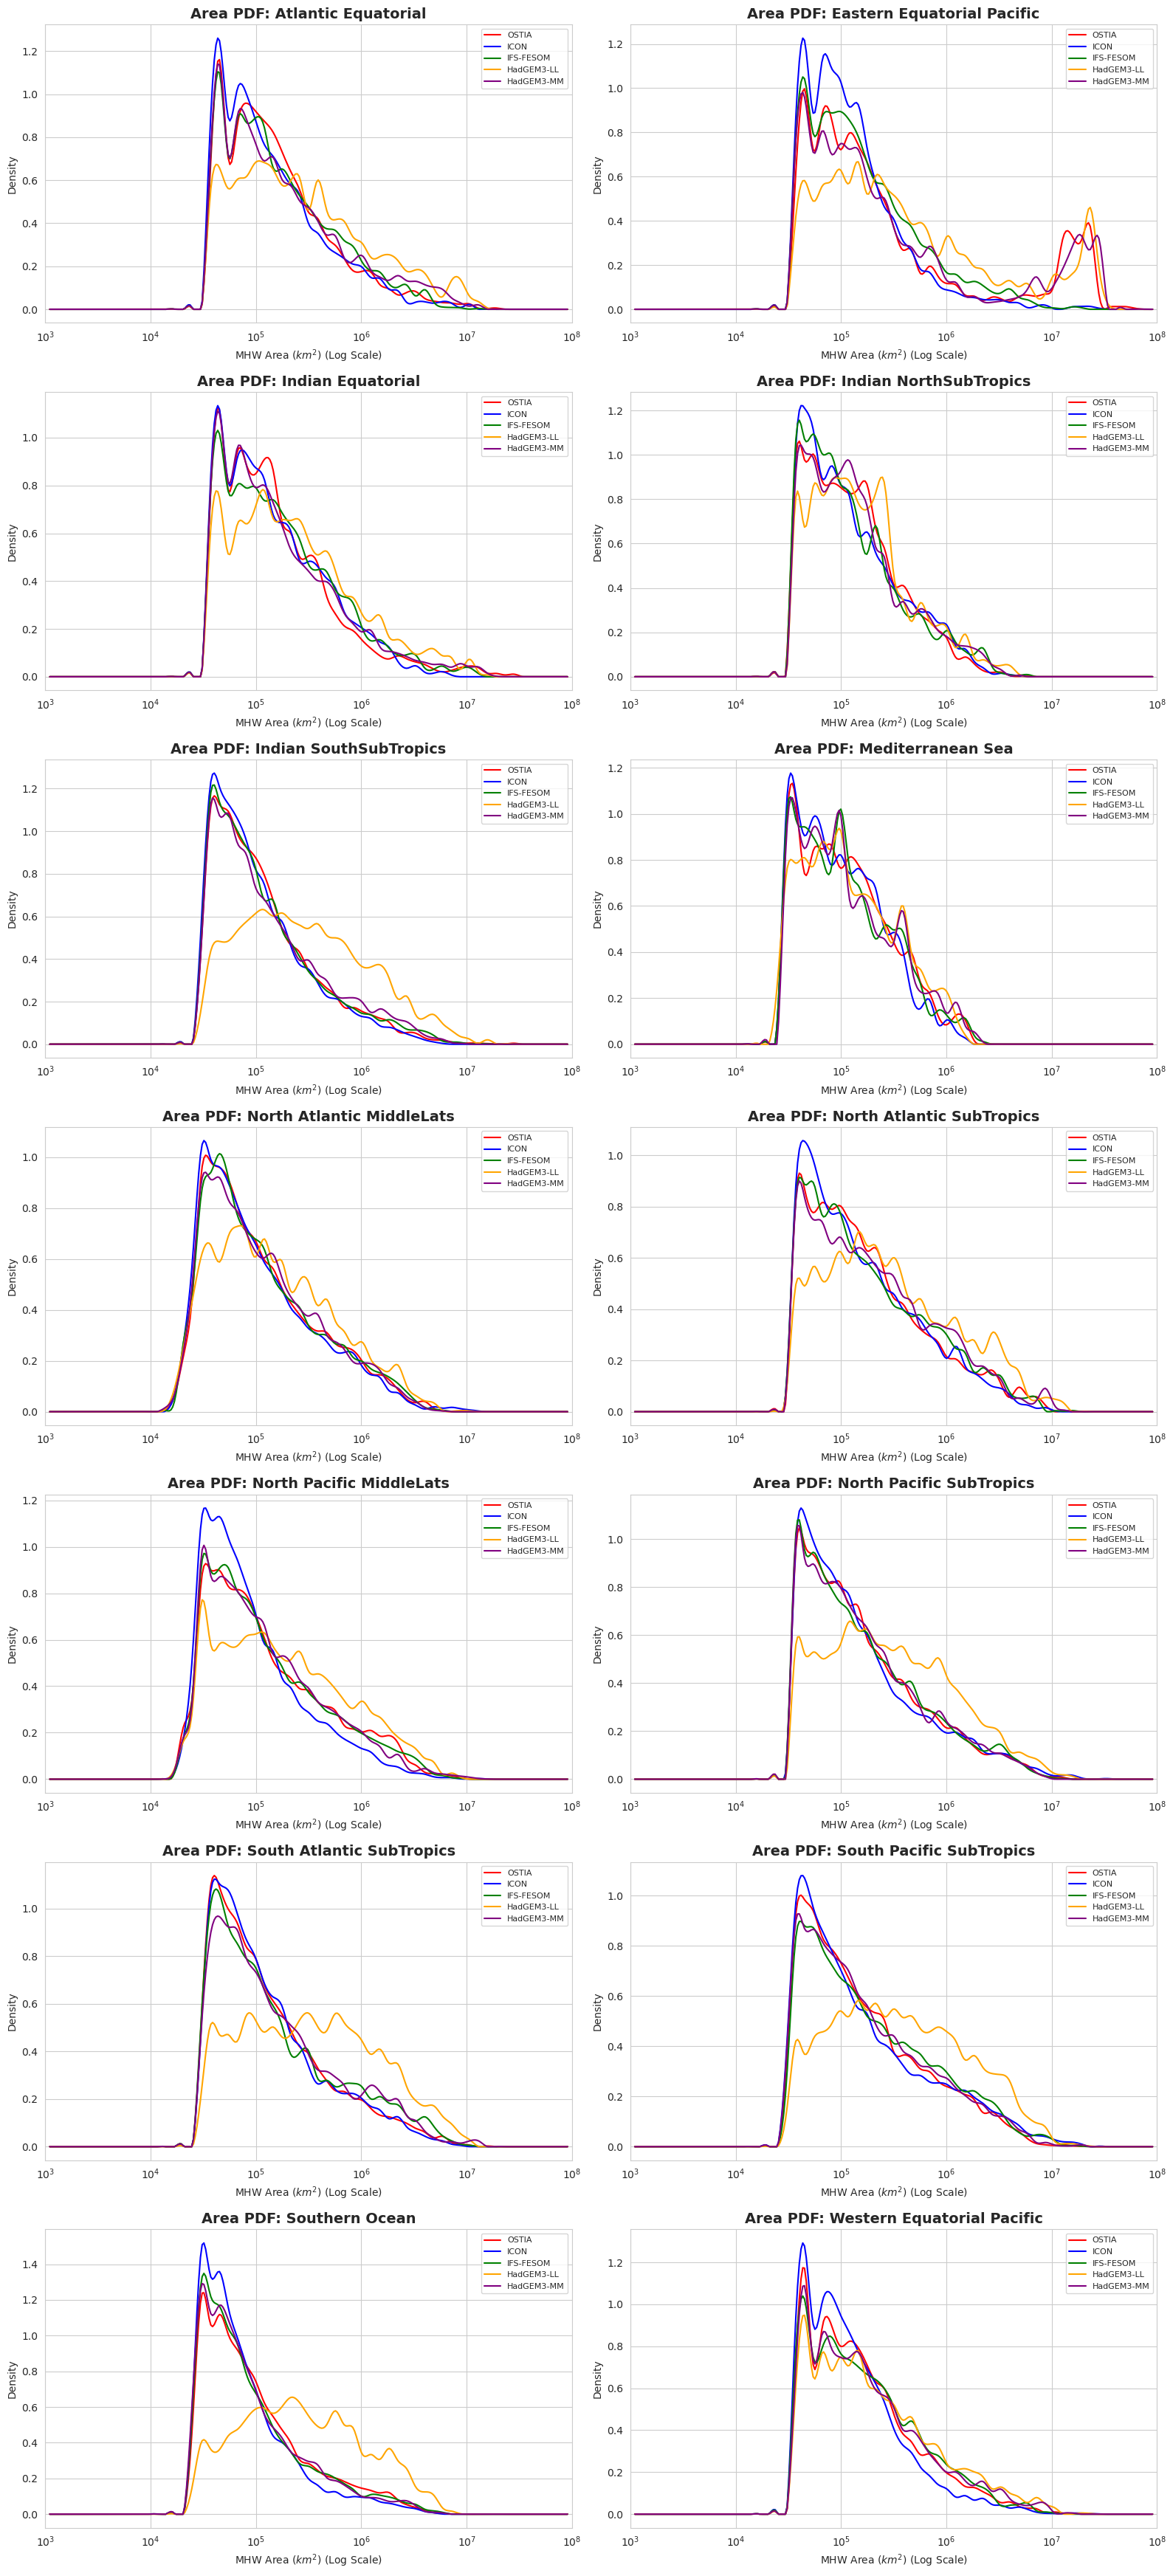

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
import math

# 1. SETUP STYLE AND METADATA
sns.set_style("whitegrid")
model_order = ['OSTIA', 'ICON', 'IFS-FESOM', 'HadGEM3-LL', 'HadGEM3-MM', 'HadGEM3-HH']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
color_map = dict(zip(model_order, colors))

# 2. DEFINE BINS (Log10 space for MHW areas)
bins = np.linspace(3, 8, 60) # 10^3 to 10^8 km2
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]

# 3. COMPUTE DISTRIBUTIONS
# We do this calculation once to store the "simple" PDF data
regional_pdfs = {}

for model_name, ds in models_dict.items():
    print(f"Processing {model_name}...")
    
    # We load the necessary 1D arrays into memory to avoid chunking errors
    # These are 1D arrays of blob properties, so they should fit in RAM easily
    all_areas = ds.total_area_km2.values
    all_regions = ds.assigned_region.values.astype(str)
    
    for region in np.unique(all_regions):
        if region in ['Open_Ocean', 'nan', 'None']: continue
        
        if region not in regional_pdfs:
            regional_pdfs[region] = {}
            
        # Filter areas for this specific region
        mask = all_regions == region
        reg_areas = all_areas[mask]
        
        # Clean zeros and NaNs
        reg_areas = reg_areas[~np.isnan(reg_areas) & (reg_areas > 0)]
        
        if len(reg_areas) > 0:
            # Create histogram
            counts, _ = np.histogram(np.log10(reg_areas), bins=bins)
            
            # Normalize to PDF (Density)
            density = counts / (counts.sum() * bin_width)
            
            regional_pdfs[region][model_name] = {
                'x': bin_centers,
                'y': density
            }

# 4. PLOTTING ALL REGIONS
unique_regions = sorted(list(regional_pdfs.keys()))
n_regions = len(unique_regions)
n_cols = 2
n_rows = math.ceil(n_regions / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), dpi=100)
axes = axes.flatten()

for i, region in enumerate(unique_regions):
    ax = axes[i]
    
    for model_name in model_order:
        if model_name in regional_pdfs[region]:
            data = regional_pdfs[region][model_name]
            x, y = data['x'], data['y']
            
            # Smooth for the Seaborn "KDE" look
            if len(x) > 5 and y.max() > 0:
                x_smooth = np.linspace(x.min(), x.max(), 300)
                spline = make_interp_spline(x, y, k=3)
                y_smooth = np.maximum(spline(x_smooth), 0)
                
                ax.plot(10**x_smooth, y_smooth, label=model_name, 
                        color=color_map[model_name], lw=1.5)

    # Standard Seaborn-style styling
    ax.set_xscale('log')
    ax.set_xlim(1e3, 1e8)
    ax.set_title(f"Area PDF: {region.replace('_', ' ')}", fontsize=14, fontweight='bold')
    ax.set_xlabel("MHW Area ($km^2$) (Log Scale)")
    ax.set_ylabel("Density")
    ax.legend(loc='upper right', fontsize=8)

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

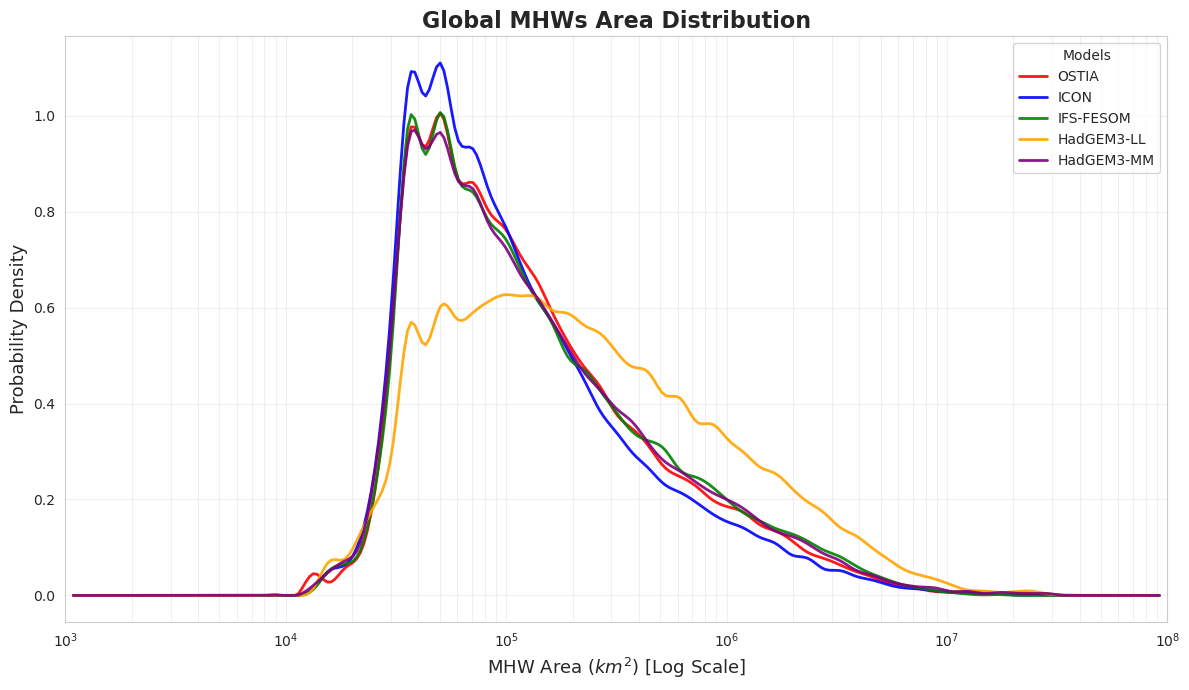

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

# 1. SETUP STYLE
sns.set_style("whitegrid")
model_order = ['OSTIA', 'ICON', 'IFS-FESOM', 'HadGEM3-LL', 'HadGEM3-MM', 'HadGEM3-HH']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
color_map = dict(zip(model_order, colors))

# 2. BINS (Log10 from 10^3 to 10^8 km2)
bins = np.linspace(3, 8, 70) 
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]

plt.figure(figsize=(12, 7), dpi=100)

# 3. COMPUTE GLOBAL PDF FOR EACH MODEL
for model_name in model_order:
    if model_name in models_dict:
        ds = models_dict[model_name]
        
        # Load all areas (ignoring regional assignment)
        # Using .values to bypass Dask chunking issues
        global_areas = ds.total_area_km2.values
        
        # Clean data (No NaNs, No Zeros)
        clean_areas = global_areas[~np.isnan(global_areas) & (global_areas > 0)]
        
        if len(clean_areas) > 0:
            # Histogram in log space
            counts, _ = np.histogram(np.log10(clean_areas), bins=bins)
            
            # Normalize to Density (PDF)
            # Density = counts / (total_count * bin_width)
            density = counts / (counts.sum() * bin_width)
            
            # Smoothing for the KDE aesthetic
            x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)
            spline = make_interp_spline(bin_centers, density, k=3)
            y_smooth = np.maximum(spline(x_smooth), 0)
            
            # Plot against raw area (10^x) for log-x scale
            plt.plot(10**x_smooth, y_smooth, 
                     label=model_name, 
                     color=color_map[model_name], 
                     lw=2, 
                     alpha=0.9)


# 4. FINAL STYLING
plt.xscale('log')
plt.xlim(1e3, 1e8)

# Improving the labels for clarity
plt.title("Global MHWs Area Distribution", fontsize=16, fontweight='bold')
plt.xlabel("MHW Area ($km^2$) (Log Scale)", fontsize=13) # Explicitly stating Log Scale
plt.ylabel("Probability Density", fontsize=13)



plt.legend(title="Models", loc='upper right', fontsize=10, frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.savefig('global_mhw_area_pdf.png', dpi=300)
plt.show()

In [72]:
import pandas as pd
import numpy as np

# 1. Define the strictly requested order
model_order = ['OSTIA', 'ICON', 'IFS-FESOM', 'HadGEM3-LL', 'HadGEM3-MM', 'HadGEM3-HH']

# 2. Check keys in your actual models_dict to handle typos (HH vs H)
actual_keys = list(models_dict.keys())
print(f"Detected keys in models_dict: {actual_keys}")

stats_list = []

for model_name in model_order:
    # Handle the case where the key might be 'HadGEM3-H' instead of 'HadGEM3-HH'
    lookup_key = model_name
    if model_name == 'HadGEM3-HH' and 'HadGEM3-HH' not in models_dict:
        if 'HadGEM3-H' in models_dict:
            lookup_key = 'HadGEM3-H'
            print(f"Note: Using 'HadGEM3-H' data for requested 'HadGEM3-HH' stats.")
    
    if lookup_key not in models_dict:
        print(f"Skipping {model_name}: Key not found in models_dict.")
        continue
        
    ds = models_dict[lookup_key]
    
    # Load 1D arrays to memory
    # total_area_km2 is the area of each blob
    # assigned_region is the region name for each blob
    all_areas = ds.total_area_km2.values
    all_regions = ds.assigned_region.values.astype(str)
    
    # Filter valid data (Area > 0 and not NaN)
    valid_mask = ~np.isnan(all_areas) & (all_areas > 0)
    clean_areas = all_areas[valid_mask]
    clean_regions = all_regions[valid_mask]
    
    if len(clean_areas) == 0:
        continue

    # --- A. GLOBAL STATS ---
    stats_list.append({
        'Model': model_name,
        'Region': '00_GLOBAL',  # Prefix with 00 to ensure it sorts to top
        'Count': len(clean_areas),
        'Min Area (km²)': np.min(clean_areas),
        'Max Area (km²)': np.max(clean_areas),
        'Mean Area (km²)': np.mean(clean_areas),
        'Median Area (km²)': np.median(clean_areas)
    })
    
    # --- B. REGIONAL STATS ---
    unique_regs = np.unique(clean_regions)
    for region in unique_regs:
        if region in ['Open_Ocean', 'nan', 'None', 'generic']: continue
        
        reg_areas = clean_areas[clean_regions == region]
        
        if len(reg_areas) > 0:
            stats_list.append({
                'Model': model_name,
                'Region': region.replace('_', ' '),
                'Count': len(reg_areas),
                'Min Area (km²)': np.min(reg_areas),
                'Max Area (km²)': np.max(reg_areas),
                'Mean Area (km²)': np.mean(reg_areas),
                'Median Area (km²)': np.median(reg_areas)
            })

# 3. Create and Format DataFrame
df_stats = pd.DataFrame(stats_list)

# Fix the GLOBAL label and Model sorting
df_stats['Region'] = df_stats['Region'].replace('00_GLOBAL', 'GLOBAL')
df_stats['Model'] = pd.Categorical(df_stats['Model'], categories=model_order, ordered=True)

# Sort by Region then by the specific Model order
df_final = df_stats.sort_values(['Region', 'Model'])

# Format with commas and no decimals for readability
pd.options.display.float_format = '{:,.0f}'.format

# 4. Display the table
print("\nMHW Area Statistics Table:")
display(df_final)

# Save to CSV for your report
df_final.to_csv('mhw_area_statistics_all_regions.csv', index=False)

Detected keys in models_dict: ['OSTIA', 'ICON', 'IFS-FESOM', 'HadGEM3-LL', 'HadGEM3-MM', 'HadGEM3-H']


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 10.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Note: Using 'HadGEM3-H' data for requested 'HadGEM3-HH' stats.

MHW Area Statistics Table:


,Model,Region,Count,Min Area (km²),Max Area (km²),Mean Area (km²),Median Area (km²)
1,OSTIA,Atlantic Equatorial,12167,"37,303","18,596,858","401,515","123,708"
16,ICON,Atlantic Equatorial,12448,"37,289","10,563,226","336,356","107,410"
31,IFS-FESOM,Atlantic Equatorial,12407,"37,289","12,446,142","380,668","127,479"
46,HadGEM3-LL,Atlantic Equatorial,6882,"37,289","15,055,952","853,389","216,247"
61,HadGEM3-MM,Atlantic Equatorial,9801,"37,289","13,406,278","553,435","134,111"
...,...,...,...,...,...,...,...
29,ICON,Western Equatorial Pacific,26028,"37,289","26,439,444","295,375","103,726"
44,IFS-FESOM,Western Equatorial Pacific,22927,"37,289","13,623,063","404,866","139,554"
59,HadGEM3-LL,Western Equatorial Pacific,14339,"37,289","23,366,778","599,176","161,409"
74,HadGEM3-MM,Western Equatorial Pacific,15842,"37,260","16,770,686","487,918","141,281"


# plot blobs and centroids

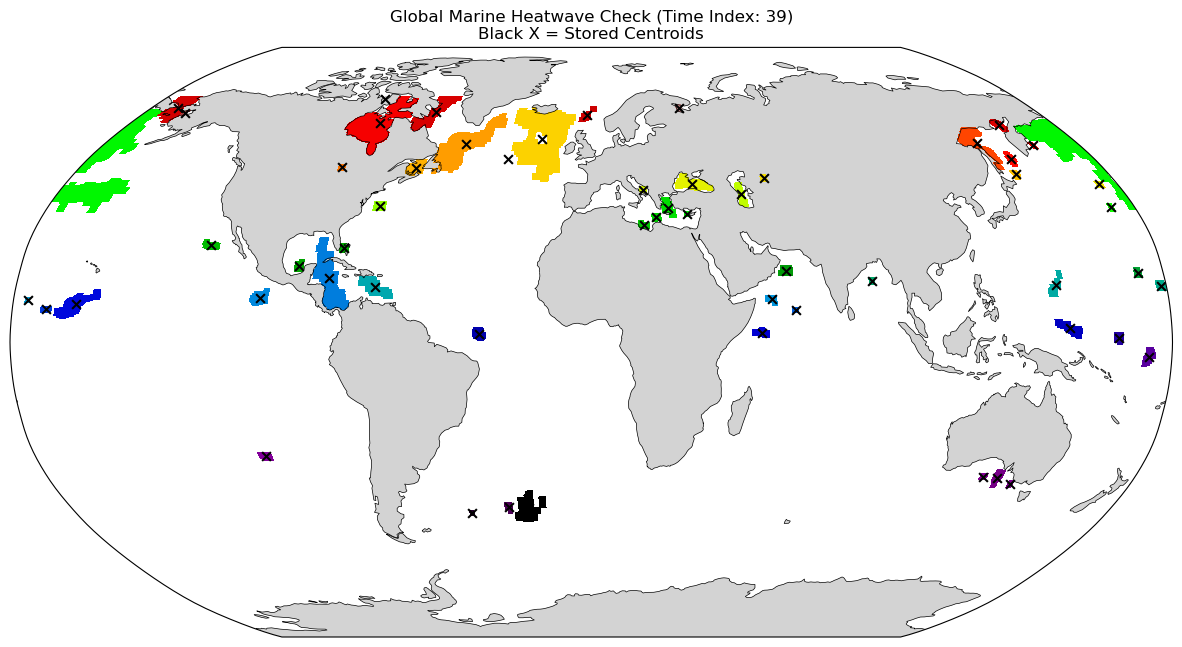

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Grab a global slice for one time step
t_idx = 39 
global_slice = ds_result.isel(time=t_idx).compute()

plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.Robinson()) # Robinson looks great for global maps
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)

# 2. Plot the ID_field (The Blobs)
# We use a categorical colormap to distinguish neighboring events
global_slice.ID_field.where(global_slice.ID_field > 0).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap='nipy_spectral', add_colorbar=False
)

# 3. Extract and Plot Centroids
# We extract the 1D arrays of the data
lons = global_slice.centroid_lon.values.flatten()
lats = global_slice.centroid_lat.values.flatten()
ids = global_slice.ID_field.values.flatten()

# Filter for active pixels
mask = ids > 0
active_lons = lons[mask]
active_lats = lats[mask]

# We use a set to ensure we only plot one X per unique event
# (Rounding slightly helps avoid precision noise from different pixels)
unique_pts = set(zip(np.round(active_lons, 3), np.round(active_lats, 3)))

for lon, lat in unique_pts:
    ax.scatter(lon, lat, color='black', marker='x', s=40, 
               transform=ccrs.PlateCarree(), zorder=3)

plt.title(f"Global Marine Heatwave Check (Time Index: {t_idx})\nBlack X = Stored Centroids")
plt.show()

# CHECK RESULTS

In [ ]:
from scipy.ndimage import binary_closing as scipy_binary_closing
from scipy.ndimage import binary_opening as scipy_binary_opening
from scipy.ndimage import label as scipy_label
from scipy.ndimage import sum as scipy_sum
from skimage.measure import regionprops
from dask_image.ndmorph import binary_opening as dask_binary_opening
from dask_image.ndmorph import binary_closing as dask_binary_closing

# 24/12/25 - INTEGRATED TEMPORAL & SPATIAL MHW PROCESSOR

# --- 1. PREP MASK & WEIGHTS ---
land_mask_2d = ds.mask.compute().values.astype(bool)

# Calculate physical area weights (km2) for a spherical Earth
R_earth = 6371.0
res = 0.25
lat_r = np.radians(ds.lat)
dlat, dlon = np.radians(res), np.radians(res)
grid_area_2d = (R_earth**2 * np.abs(np.sin(lat_r + dlat/2) - np.sin(lat_r - dlat/2)) * dlon).astype(np.float32)
grid_area_2d_slice = (xr.ones_like(ds.extreme_events.isel(time=0)) * grid_area_2d).values

# --- 2. TEMPORAL CLEANING (Hobday Logic) ---
# Enforce 5-day minimum duration and close gaps of up to 2 days
T_fill, T_min = 2, 5
# Structures act on (Time, Lat, Lon). We only want to bridge/filter along Time (dim 0).
time_open_struct = np.ones((T_min, 1, 1), dtype=bool)
time_close_struct = np.ones((T_fill + 1, 1, 1), dtype=bool)

print("Starting Temporal Filtering (5-day min, 2-day gap)...")
# Note: o_ex must be chunked significantly in time for this to be efficient
o_ex_raw = ds.extreme_events.chunk({'time': -1, 'lat': 100, 'lon': 100}) 

# 1. Opening: Remove events < 5 days
temp_cleaned = dask_binary_opening(o_ex_raw.data, structure=time_open_struct)
# 2. Closing: Fill gaps <= 2 days
temp_cleaned = dask_binary_closing(temp_cleaned, structure=time_close_struct)

# Wrap back to Xarray and re-chunk for spatial processing (1 day per chunk)
o_ex_filtered = xr.DataArray(temp_cleaned, coords=ds.extreme_events.coords, dims=ds.extreme_events.dims)
o_ex_filtered = o_ex_filtered.chunk({'time': 1, 'lat': -1, 'lon': -1})
# 1. Extract the raw binary slice at time=10
# We use the filtered data (after Hobday temporal cleaning)
binary_slice = o_ex_filtered.isel(time=10).compute().values.astype(bool)
land_mask = land_mask_2d

# --- REPLICATE PIPELINE STEPS MANUALLY ---

# Step A: Raw Input (Ocean only)
step1_raw = binary_slice & land_mask

# Step B: After Spatial Closing (Filling Gaps)
R_fill = 3
kernel = np.ones((R_fill*2+1, R_fill*2+1))
pad = 10
wrapped = np.pad(step1_raw, ((0,0), (pad, pad)), mode='wrap')
closed_wrapped = scipy_binary_closing(wrapped, structure=kernel)
step2_closed = closed_wrapped[:, pad:-pad] & land_mask

# Step C: After Opening (Removing Noise)
step3_opened = scipy_binary_opening(step2_closed, structure=kernel) & land_mask

# Step D: Labeled Blobs
# (Using the same logic as your script)
lbl, n = scipy_label(step3_opened, structure=np.ones((3,3)))

# --- VISUALIZATION ---

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()
# Create a mask to hide the "False" (non-event) areas in your plots
# This allows the land underneath to be visible in the background
def mask_zeros(data):
    return np.where(data > 0, data, np.nan)

from matplotlib.colors import ListedColormap


# 1. Setup Projections & Extent
# Assuming your data is global PlateCarree (standard lat/lon)
data_proj = ccrs.PlateCarree()
# [lon_min, lon_max, lat_min, lat_max]
img_extent = [ds.lon.min(), ds.lon.max(), ds.lat.min(), ds.lat.max()]

# 2. Define Colormaps
red_cmp = ListedColormap(['none', 'darkred'])

# 3. Create Figure with Cartopy projection
fig, axes = plt.subplots(2, 2, figsize=(18, 12), 
                         subplot_kw={'projection': data_proj}, 
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- Plotting Functions ---

# Plot 1: Raw
axes[0].imshow(step1_raw, origin='lower', cmap=red_cmp, 
               extent=img_extent, transform=data_proj, zorder=10)
axes[0].set_title("1. MHWs", fontsize=14)

# Plot 2: After Closing
axes[1].imshow(step2_closed, origin='lower', cmap=red_cmp, 
               extent=img_extent, transform=data_proj, zorder=10)
axes[1].set_title("2. After Spatial Closing", fontsize=14)

# Plot 3: After Opening
axes[2].imshow(step3_opened, origin='lower', cmap=red_cmp, 
               extent=img_extent, transform=data_proj, zorder=10)
axes[2].set_title("3. After Spatial Opening", fontsize=14)

# Plot 4: Labels
axes[3].imshow(np.where(lbl > 0, lbl, np.nan), origin='lower', cmap='nipy_spectral', 
               extent=img_extent, transform=data_proj, zorder=10, interpolation='nearest')
axes[3].set_title(f"4. Final Labeled Blobs (Found {n})", fontsize=14)

# --- General Styling (Cartopy Features) ---
for ax in axes:
    # Set background to white (Ocean)
    ax.set_facecolor('white')
    
    # Add high-resolution Land (Black)
    # We use 'facecolor' for the land and 'edgecolor' for the coastline
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)





In [9]:
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_area_mhws.zarr'
ds_result_ostia=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'iconhist_area_mhws.zarr'
ds_result_icon=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ifsfesom_area_mhws.zarr'
ds_result_ifs=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'LL_area_mhws.zarr'
ds_result_LL=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_area_mhws.zarr'
ds_result_MM=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'HH_area_mhws.zarr'
ds_result_MM=xr.open_zarr(file_name)

In [3]:
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_regional_area.zarr'
region_ostia=xr.open_zarr(file_name)


file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'iconhist_regional_area.zarr'
region_icon=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ifsfesom_regional_area.zarr'
region_ifs=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'LL_regional_area.zarr'
region_LL=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_regional_area.zarr'
region_MM=xr.open_zarr(file_name)

file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MM_regional_area.zarr'
region_HH=xr.open_zarr(file_name)

In [12]:
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'iconhist_regional_area.zarr'
#region_icon=xr.open_zarr(file_name)
# Convert the Zarr assignments back to a DataFrame
df_plot = region_MM.to_dataframe().reset_index()

# Filter out 'Open_Ocean' if you only want to see the specific named regions
df_plot = df_plot[df_plot['assigned_region'] != 'Open_Ocean']



In [17]:
# LOAD MASKS
all_models = ['IFS-FESOM']

mask_save_dir = Path('/scratch/b/b382616/mhws/DV8/extremes_model_masks')

# All model names

masks_dict = {}

for model in all_models:
    # Find the mask file for this model
    mask_files = list(mask_save_dir.glob(f'*{model}*.zarr'))
    
    if mask_files:
        mask_file = mask_files[0]
        print(f"Loading {model} mask from {mask_file.name}")
        
        mask_ds = xr.open_zarr(str(mask_file))
        
        # For HadGEM models, select latitude range
        if model.startswith('HadGEM3-'):
            mask_ds = mask_ds.sel(lat=slice(-50, 70))
            print(f"  Selected lat range -50 to 70")
        
        masks_dict[model] = mask_ds
        print(f"  ✓ Loaded {len(mask_ds.data_vars)} regions")
    else:
        print(f"Warning: No mask file found for {model}")

print(f"\nSuccessfully loaded masks for {len(masks_dict)} models")

Loading IFS-FESOM mask from extremes_IFS-FESOM_481x1440_-2130404455801615551_region_masks.zarr
  ✓ Loaded 15 regions

Successfully loaded masks for 1 models


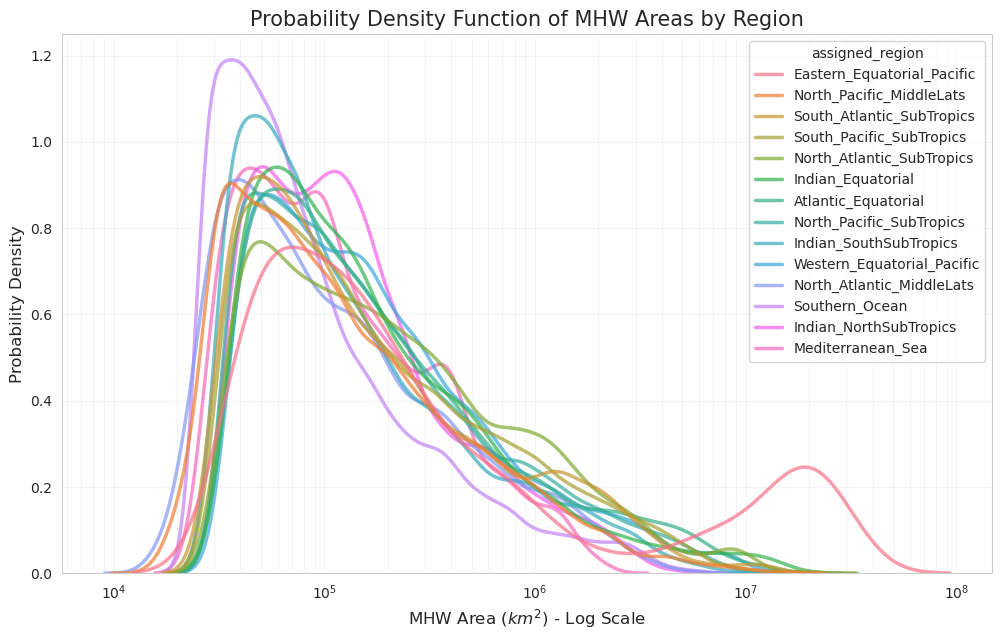

In [13]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# We use log_scale=True because area ranges from 10^2 to 10^7+
sns.kdeplot(
    data=df_plot, 
    x="total_area_km2", 
    hue="assigned_region", 
    log_scale=True, 
    common_norm=False,  # This ensures each curve integrates to 1 independently
    linewidth=2.5,
    alpha=0.7
)

plt.title("Probability Density Function of MHW Areas by Region", fontsize=15)
plt.xlabel("MHW Area ($km^2$) - Log Scale", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [13]:
# Check the largest blobs
top_blobs = df_assignments.sort_values('total_area_km2', ascending=False).head(5)
print("--- Top 5 Largest Blobs ---")
print(top_blobs[['id', 'assigned_region', 'total_area_km2']])

max_val = df_assignments['total_area_km2'].max()
if max_val > 1e10:
    print(f"\nALERT: Max area is {max_val:,.0f}. Logic still double-summing or units are in m^2.")
elif max_val > 1e7:
    print(f"\nNOTE: Max area is {max_val:,.0f}. These are likely very large ENSO-scale events.")
else:
    print(f"\nSUCCESS: Max area is {max_val:,.0f}. Units look correct for km^2.")

--- Top 5 Largest Blobs ---
         id             assigned_region  total_area_km2
12637  9356    North_Pacific_SubTropics      64788344.0
12844  9504    North_Pacific_SubTropics      64706032.0
12742  9434    North_Pacific_SubTropics      64351264.0
12516  9274  Eastern_Equatorial_Pacific      59942084.0
12403  9198  Eastern_Equatorial_Pacific      59098920.0

NOTE: Max area is 64,788,344. These are likely very large ENSO-scale events.


In [20]:
# 1. Filter assignments for the target region
target_region = 'Eastern_Equatorial_Pacific'
region_ids = df_assignments[df_assignments['assigned_region'] == target_region]['id'].values

print(f"Found {len(region_ids)} unique MHW blobs assigned to {target_region}")

# 2. Create a 2D Frequency Map (How many times each pixel was part of a blob in this region)
# This is memory-efficient because we reduce the time dimension
region_mask = ds_result.unique_id.isin(region_ids)
frequency_map = region_mask.sum(dim='time').compute()

Found 16289 unique MHW blobs assigned to Eastern_Equatorial_Pacific


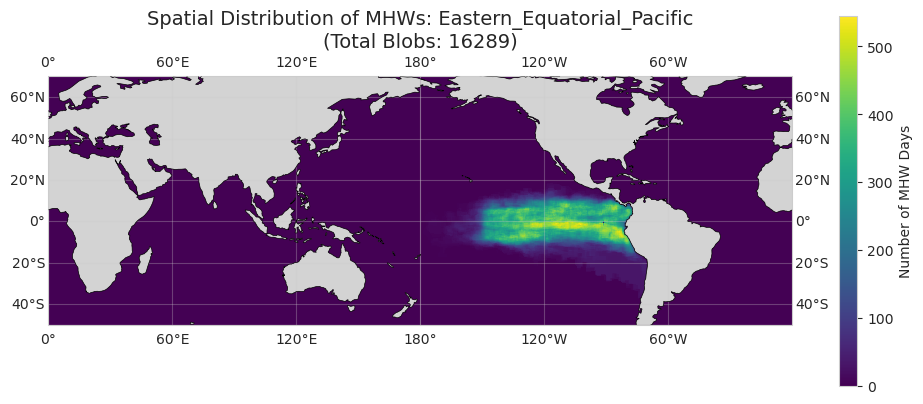

In [21]:


fig = plt.figure(figsize=(12, 6))
# Center at 180 to see the Pacific clearly
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# Add geographic context
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)

# Plot the frequency map
# If you want to see if they are cut at the dateline, watch the 180 line (center of plot)
im = frequency_map.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    add_colorbar=True,
    cbar_kwargs={'label': 'Number of MHW Days', 'shrink': 0.8}
)

# Focus the map on the Equatorial Pacific
# Coordinates: ~20S to 20N, and 120E to 70W


plt.title(f"Spatial Distribution of MHWs: {target_region}\n(Total Blobs: {len(region_ids)})", fontsize=14)
plt.show()

New Biggest ID: 275032
Corrected Area: 32,415,712 km^2


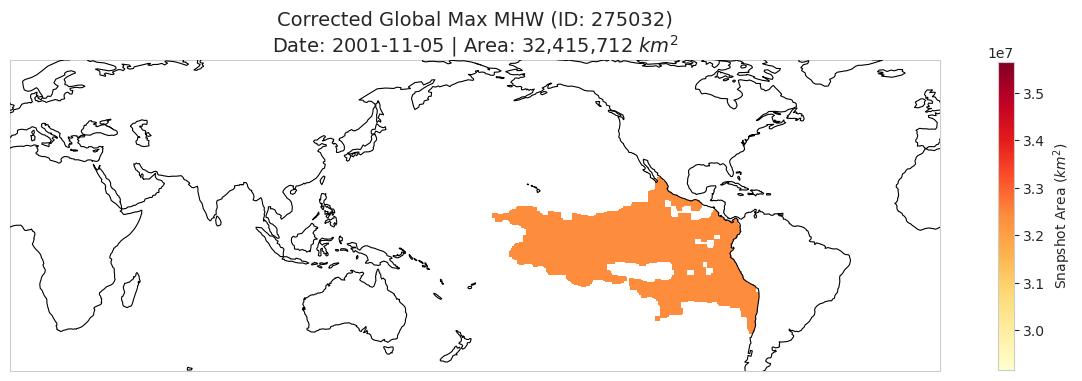

In [12]:
# Identify the new biggest ID
new_top = df_assignments.sort_values('total_area_km2', ascending=False).head(1)
biggest_id = new_top['id'].values[0]
biggest_area = new_top['total_area_km2'].values[0]

print(f"New Biggest ID: {biggest_id}")
print(f"Corrected Area: {biggest_area:,.0f} km^2")

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Find the day it occurred
presence = (ds_result.unique_id == biggest_id).any(dim=['lat', 'lon']).compute()
time_idx = np.where(presence.values)[0][0]
blob_date = ds_result.time.values[time_idx]

# 2. Extract slice
day_slice = ds_result.isel(time=time_idx).compute()
blob_mask = day_slice.unique_id == biggest_id

# 3. Plotting
fig = plt.figure(figsize=(15, 8))
# We use Central Longitude 180 to see the Pacific as one continuous piece
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

#ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

# Plot the area values
# Using 'inferno' or 'YlOrRd' helps show the "core" of the heatwave
im = ax.pcolormesh(day_slice.lon, day_slice.lat, 
                   day_slice.mhw_area_km2.where(blob_mask),
                   transform=ccrs.PlateCarree(),
                   cmap='YlOrRd', zorder=1)

# Formatting
plt.title(f"Corrected Global Max MHW (ID: {int(biggest_id)})\nDate: {np.datetime_as_string(blob_date, unit='D')} | Area: {biggest_area:,.0f} $km^2$", 
          fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.5, label='Snapshot Area ($km^2$)')

# Focus on the Equatorial Pacific

plt.show()

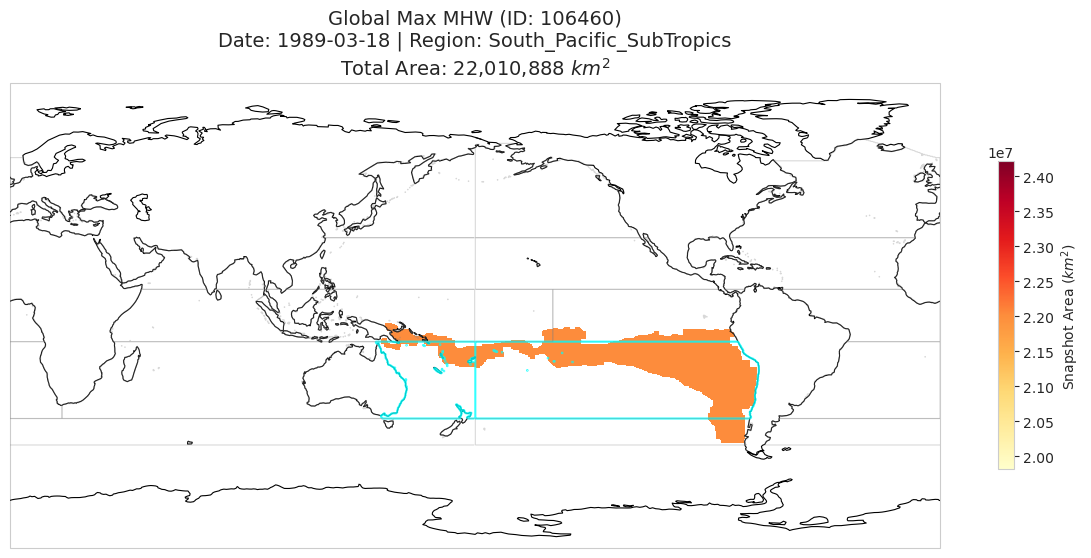

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Find the day it occurred
presence = (ds_result.unique_id == biggest_id).any(dim=['lat', 'lon']).compute()
time_idx = np.where(presence.values)[0][0]
blob_date = ds_result.time.values[time_idx]
assigned_reg = df_assignments[df_assignments['id'] == biggest_id]['assigned_region'].values[0]

# 2. Extract slice
day_slice = ds_result.isel(time=time_idx).compute()
blob_mask = day_slice.unique_id == biggest_id

# 3. Plotting
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

# --- NEW: OVERLAY REGIONAL MASK BOUNDARIES ---
# We iterate through regions to draw their outlines
for reg_name in region_names:
    mask = masks_dict['IFS-FESOM'][reg_name]
    
    # Choose a specific color for the assigned region, light gray for others
    color = 'cyan' if reg_name == assigned_reg else '0.5'
    alpha = 0.8 if reg_name == assigned_reg else 0.3
    linewidth = 1.5 if reg_name == assigned_reg else 0.8
    
    ax.contour(mask.lon, mask.lat, mask, levels=[0.5], 
               colors=color, linewidths=linewidth, alpha=alpha,
               transform=ccrs.PlateCarree(), zorder=4)

# Plot the area values of the blob
im = ax.pcolormesh(day_slice.lon, day_slice.lat, 
                   day_slice.mhw_area_km2.where(blob_mask),
                   transform=ccrs.PlateCarree(),
                   cmap='YlOrRd', zorder=1)

# Formatting
plt.title(f"Global Max MHW (ID: {int(biggest_id)})\n"
          f"Date: {np.datetime_as_string(blob_date, unit='D')} | Region: {assigned_reg}\n"
          f"Total Area: {biggest_area:,.0f} $km^2$", fontsize=14)

plt.colorbar(im, ax=ax, shrink=0.5, label='Snapshot Area ($km^2$)')

# Focus on the relevant area (Equatorial Pacific)

plt.show()

Creating footprint for IDs: [380357 380223 380263 380135 380330 380179 379698 380299 379737 379661]


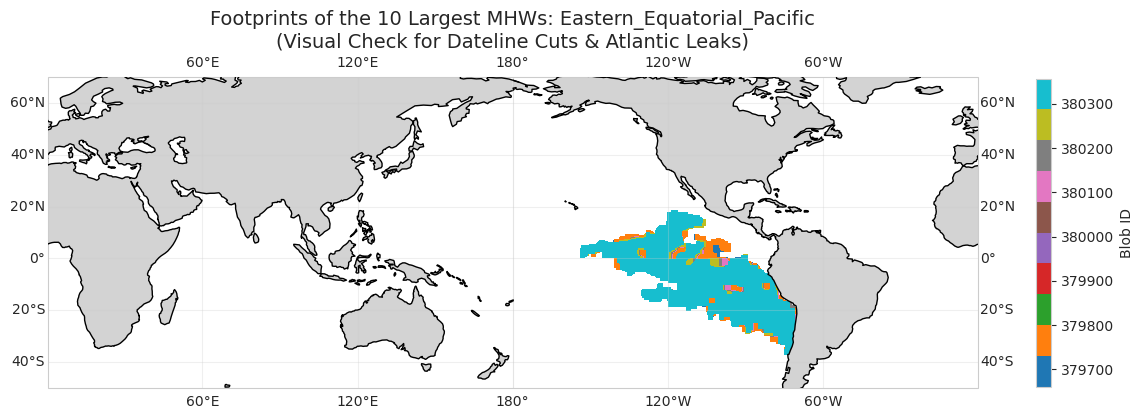

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Get the IDs of the top 10 largest Eastern Pacific blobs
target_region = 'Eastern_Equatorial_Pacific'
top_10_ids = df_assignments[df_assignments['assigned_region'] == target_region]\
                .sort_values('total_area_km2', ascending=False).head(10)['id'].values

# 2. Create a 2D "Footprint" map
# We collapse the time dimension to see where these 10 blobs existed
# Each pixel will show the ID of the largest blob that touched it
print(f"Creating footprint for IDs: {top_10_ids}")
footprint_ids = ds_result.unique_id.where(ds_result.unique_id.isin(top_10_ids)).max(dim='time').compute()

# 3. Plotting
fig = plt.figure(figsize=(15, 8))
# central_longitude=180 is key to see if the 'cut' at the dateline is fixed
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
ax.gridlines(draw_labels=True, alpha=0.3)

# Plotting the IDs with a discrete colormap to distinguish different blobs
im = footprint_ids.where(footprint_ids > 0).plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='tab10', # Discrete colors for distinct blobs
    add_colorbar=True,
    cbar_kwargs={'shrink': 0.5, 'label': 'Blob ID'},
    zorder=1
)

# Set extent to see the Pacific and the "Leak Zone" (Panama)

plt.title(f"Footprints of the 10 Largest MHWs: {target_region}\n(Visual Check for Dateline Cuts & Atlantic Leaks)", fontsize=14)
plt.show()

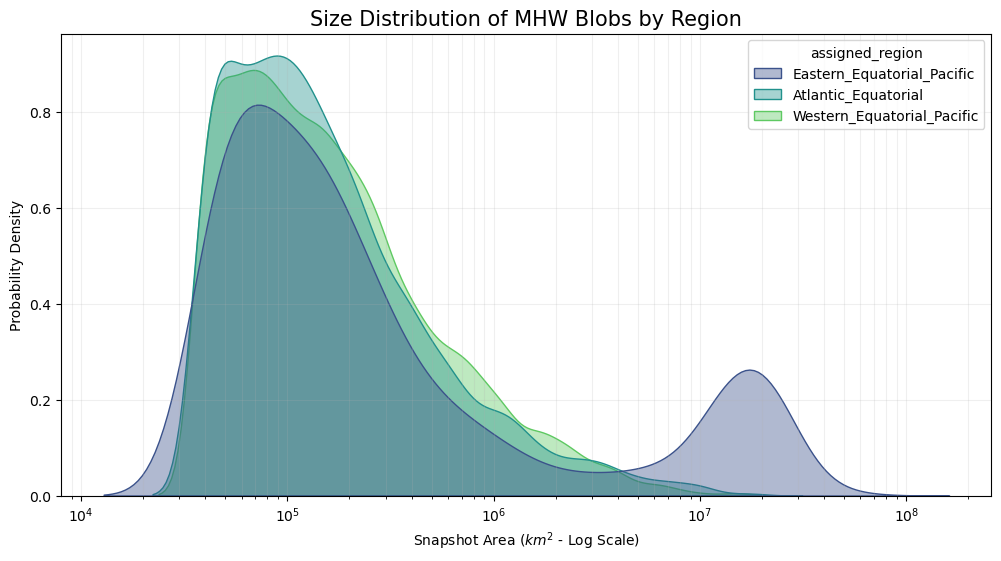

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the main regions of interest
target_regions = ['Western_Equatorial_Pacific', 'Eastern_Equatorial_Pacific', 'Atlantic_Equatorial']
plot_df = df_assignments[df_assignments['assigned_region'].isin(target_regions)]

plt.figure(figsize=(12, 6))

# Plot the Probability Density Function (PDF) using a Log Scale for Area
sns.kdeplot(data=plot_df, x='total_area_km2', hue='assigned_region', 
            fill=True, common_norm=False, palette='viridis', alpha=0.4, log_scale=True)

plt.title("Size Distribution of MHW Blobs by Region", fontsize=15)
plt.xlabel("Snapshot Area ($km^2$ - Log Scale)")
plt.ylabel("Probability Density")
plt.grid(True, which="both", ls="-", alpha=0.2)

# Set scientific notation for clarity on the x-axis if needed
plt.show()

In [7]:
save_path = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'MHW_regional_area_OSTIA_2.zarr'
ds_ostia=xr.open_zarr(save_path)

In [39]:
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'DV8' / 'ostia_area_mhws_2.zarr'
ds_result_ostia=xr.open_zarr(file_name)

# OG area workflow

In [7]:
Ok. I'm restarting the kernel and running this:

o_ex=o_ex.chunk(chunks={'time': 100, 'lat': -1, 'lon': -1})
data_bin=o_ex

T_fill = 2
T_min = 5

time_close = np.ones(T_fill+1, dtype=bool)
time_open = np.ones(T_min, dtype=bool)


data_opened=binary_opening(data_bin.data, structure=time_open[:,np.newaxis,np.newaxis])
data_mhws=binary_closing(data_opened, structure=time_close[:,np.newaxis,np.newaxis])

da_mhws=xr.DataArray(data_mhws, name="MHWs",
                   coords=data_bin.coords,
                   dims=data_bin.dims,
                   attrs=data_bin.attrs)

R_fill=3

spatial_kernel = np.ones((R_fill*2+1,R_fill*2+1))
data_sp_closed = binary_closing(data_mhws, structure=spatial_kernel[np.newaxis,:])
data_sp_opened = binary_opening(data_sp_closed, structure=spatial_kernel[np.newaxis,:])

da_mhws_clean=xr.DataArray(data_sp_opened, name="MHWs",
                   coords=data_bin.coords,
                   dims=data_bin.dims,
                   attrs=data_bin.attrs)

neighbours = np.zeros((3, 3, 3))
neighbours[1, :, :] = 1  # All 8 neighbours, but ignore time


object_id_field, N_objects = label(
    da_mhws_clean,
    structure=neighbours,
    wrap_axes=(2,),  # Wrap in x-direction !
)

results = persist(object_id_field, N_objects)
object_id_field, N_objects = results

# Convert to DataArray with same coordinates as input
object_id_field = (
    xr.DataArray(
        object_id_field,
        coords=data_bin.coords,
        dims=data_bin.dims,
        attrs=data_bin.attrs,
    )
    .rename("ID_field")
    .astype(np.int32)
)

object_id_field = object_id_field.persist()

R_earth = 6371.0  # km
resolution = 0.25  # deg

lat_r, lon_r, dlat, dlon = (
    np.radians(object_id_field.lat),
    np.radians(object_id_field.lon),
    np.radians(resolution),
    np.radians(resolution),
)
grid_area = (xr.ones_like(object_id_field) * (R_earth**2 * np.abs(np.sin(lat_r + dlat / 2) - np.sin(lat_r - dlat / 2)) * dlon)).astype(np.float32)


area=dask_image.ndmeasure.sum_labels(grid_area,object_id_field,range(1,N_objects+1))
area_int = area.round().astype(np.int64)
area_int.compute()


<xarray.DataArray 'extreme_events' (time: 35, lat: 480, lon: 1440)> Size: 24MB
dask.array<getitem, shape=(35, 480, 1440), dtype=bool, chunksize=(10, 480, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 280B 1983-01-01T12:00:00 ... 1983-02-04T12...
  * lat      (lat) float32 2kB -49.88 -49.62 -49.38 -49.12 ... 69.38 69.62 69.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9